In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

In [2]:
np.random.seed(7)

class_0 = np.random.randn(200, 2) + np.array([2, 2])
class_1 = np.random.randn(200, 2) + np.array([6, 6])
class_2 = np.random.randn(200, 2) + np.array([4, 8])

X = np.vstack((class_0, class_1, class_2))

y = np.array(
    [0] * 200 +
    [1] * 200 +
    [2] * 200
)

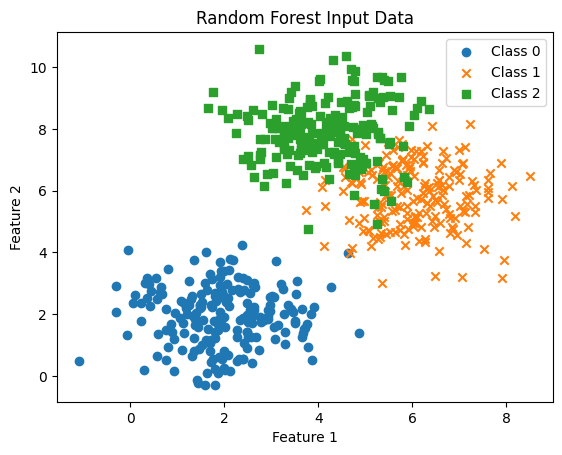

In [3]:
plt.figure()

plt.scatter(
    class_0[:, 0],
    class_0[:, 1],
    marker='o',
    label='Class 0'
)

plt.scatter(
    class_1[:, 0],
    class_1[:, 1],
    marker='x',
    label='Class 1'
)

plt.scatter(
    class_2[:, 0],
    class_2[:, 1],
    marker='s',
    label='Class 2'
)

plt.title("Random Forest Input Data")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.legend()

plt.show()

In [4]:
np.random.seed(7)

class_0 = np.random.randn(200, 2) + np.array([2, 2])
class_1 = np.random.randn(200, 2) + np.array([6, 6])
class_2 = np.random.randn(200, 2) + np.array([4, 8])

X = np.vstack((class_0, class_1, class_2))

y = np.array(
    [0] * 200 +
    [1] * 200 +
    [2] * 200
)

print("Input data shape:", X.shape)
print("Target labels shape:", y.shape)

Input data shape: (600, 2)
Target labels shape: (600,)


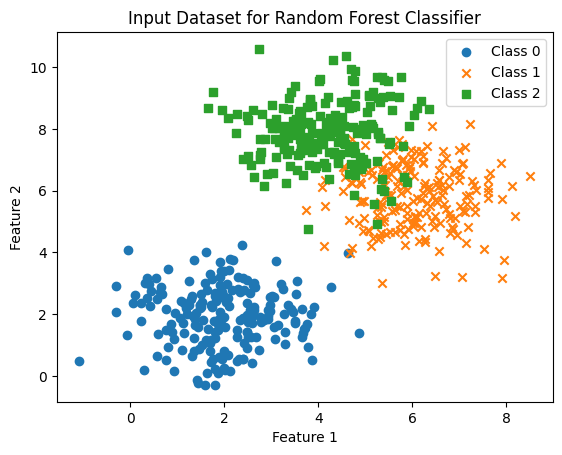

In [5]:
plt.figure()

plt.scatter(class_0[:, 0], class_0[:, 1], marker='o', label='Class 0')
plt.scatter(class_1[:, 0], class_1[:, 1], marker='x', label='Class 1')
plt.scatter(class_2[:, 0], class_2[:, 1], marker='s', label='Class 2')

plt.title("Input Dataset for Random Forest Classifier")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=5
)

In [7]:
params = {
    'n_estimators': 100,
    'max_depth': 4,
    'random_state': 0
}

classifier = RandomForestClassifier(**params)

classifier.fit(X_train, y_train)

RandomForestClassifier(max_depth=4, random_state=0)

In [8]:
def visualize_classifier(classifier, X, y, title):

    x_min, x_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
    y_min, y_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

    step_size = 0.01

    x_values, y_values = np.meshgrid(
        np.arange(x_min, x_max, step_size),
        np.arange(y_min, y_max, step_size)
    )

    mesh_output = classifier.predict(
        np.c_[x_values.ravel(), y_values.ravel()]
    )

    mesh_output = mesh_output.reshape(x_values.shape)

    plt.figure()

    plt.pcolormesh(
        x_values,
        y_values,
        mesh_output,
        shading='auto'
    )

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        edgecolors='black'
    )

    plt.title(title)

    plt.show()

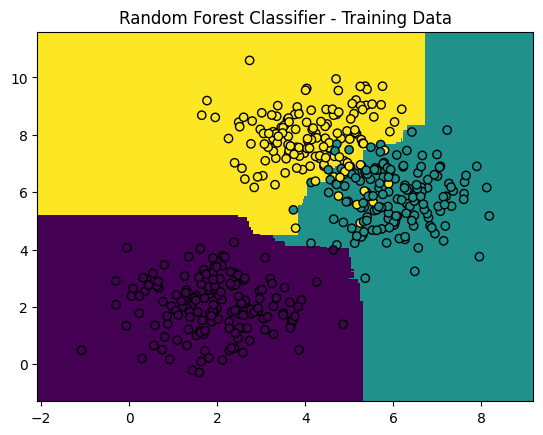

In [9]:
visualize_classifier(
    classifier,
    X_train,
    y_train,
    "Random Forest Classifier - Training Data"
)

In [10]:
y_test_pred = classifier.predict(X_test)

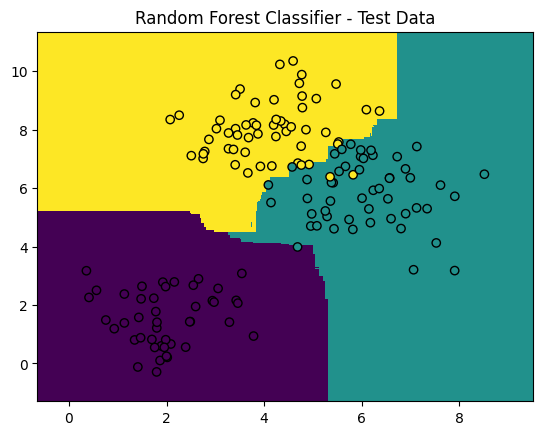

In [11]:
visualize_classifier(
    classifier,
    X_test,
    y_test,
    "Random Forest Classifier - Test Data"
)

In [12]:
class_names = ['Class-0', 'Class-1', 'Class-2']

print("\n" + "#" * 50)
print("\nRandom Forest Classifier performance on training dataset\n")

y_train_pred = classifier.predict(X_train)

print(
    classification_report(
        y_train,
        y_train_pred,
        target_names=class_names
    )
)

print("\n" + "#" * 50)
print("\nRandom Forest Classifier performance on test dataset\n")

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=class_names
    )
)

print("\n" + "#" * 50)


##################################################

Random Forest Classifier performance on training dataset

              precision    recall  f1-score   support

     Class-0       1.00      1.00      1.00       156
     Class-1       0.93      0.97      0.95       149
     Class-2       0.97      0.92      0.95       145

    accuracy                           0.97       450
   macro avg       0.97      0.97      0.97       450
weighted avg       0.97      0.97      0.97       450


##################################################

Random Forest Classifier performance on test dataset

              precision    recall  f1-score   support

     Class-0       0.98      1.00      0.99        44
     Class-1       0.88      0.98      0.93        51
     Class-2       1.00      0.87      0.93        55

    accuracy                           0.95       150
   macro avg       0.95      0.95      0.95       150
weighted avg       0.95      0.95      0.95       150


###################

In [13]:
# Estimating the confidence measure of predictions

test_datapoints = np.array([
    [5, 5],
    [3, 6],
    [6, 4],
    [7, 2],
    [4, 4],
    [5, 2]
])

print("\nConfidence measure:\n")

for datapoint in test_datapoints:
    probabilities = classifier.predict_proba([datapoint])[0]

    predicted_class = "Class-" + str(np.argmax(probabilities))

    print("Datapoint:", datapoint)
    print("Predicted class:", predicted_class)
    print("Probability values:", probabilities)
    print()


Confidence measure:

Datapoint: [5 5]
Predicted class: Class-1
Probability values: [0.01282696 0.78340127 0.20377176]

Datapoint: [3 6]
Predicted class: Class-2
Probability values: [0.07279444 0.2070004  0.72020517]

Datapoint: [6 4]
Predicted class: Class-1
Probability values: [0.11014951 0.87116278 0.01868771]

Datapoint: [7 2]
Predicted class: Class-1
Probability values: [0.34       0.65656621 0.00343379]

Datapoint: [4 4]
Predicted class: Class-0
Probability values: [0.70582267 0.18445867 0.10971866]

Datapoint: [5 2]
Predicted class: Class-0
Probability values: [0.69914064 0.24057234 0.06028703]



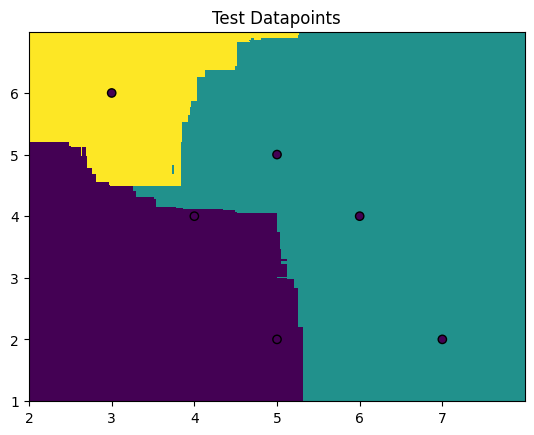

In [14]:
# Visualizing the datapoints

visualize_classifier(
    classifier,
    test_datapoints,
    [0] * len(test_datapoints),
    "Test Datapoints"
)

plt.show()